In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split

import os
# os.environ["OMP_NUM_THREADS"] = "9"


## Reading data

In [2]:
#read in the exoplanet data
df = pd.read_csv('exoplanets.csv', comment='#', low_memory=False)
# We sort by planet name
df_sorted = df.sort_values(by=['pl_name', 'default_flag'], ascending=[True, False])

# .first() will take the first non-null value it encounters for each column in the group
df_combined = df_sorted.groupby('pl_name', as_index=False).first()

features = df_combined[['pl_rade', 'pl_masse', 'pl_dens', 'pl_orbper']].copy()
e_massg = 5.97e27
e_radcm  = 6.37e8

features['pl_dens'] = features['pl_masse']/(4.0/3.0*np.pi*features['pl_rade']**3) * (e_massg/e_radcm**3)

sample = features.dropna()
sample_arr = sample.values

log_data = np.log10(sample_arr)
norm_koeffs =np.mean(log_data, axis = 0)
log_data = log_data/norm_koeffs
log_data_MR = log_data[:,:2]
log_data_RD = log_data[:,1:3]

print(log_data.shape)

(1684, 4)


In [3]:
ss_planets = pd.read_csv('Solar_system.csv', usecols=[2,3,4, 6], skiprows=2,
                         names=['radius', 'mass', 'bulk density', 'orbital period'])
# ss_planets['solar mass'] = 1
ss_planets['mass'] = ss_planets.apply(lambda x: float(x['mass'].split()[0]), axis=1)
ss_planets['radius'] = ss_planets.apply(lambda x: float(x['radius'].split()[0]), axis=1)
ss_planets['orbital period'] = ss_planets.apply(lambda x: float(x['orbital period'].split()[0]), axis=1)
ss_planets['bulk density'] = ss_planets.apply(lambda x: float(x['bulk density'].split()[0]), axis=1)

ss_planets['mass'] = ss_planets['mass']/ss_planets.loc[2]['mass']
ss_planets['radius'] = ss_planets['radius']/ss_planets.loc[2]['radius']
ss_planets['orbital period'] = ss_planets['orbital period']*365.2425
ss_planets['bulk density'] = ss_planets['bulk density']

# ss_smax = ((ss_planets['orbital period'].values)**2)**(1/3)
# ss_planets['insol'] = 3.827e26/(4*np.pi*ss_smax**2)
# ss_planets['insol'] = ss_planets['insol']/ss_planets.loc[2]['insol']

planet_names  = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
ss_feat = ss_planets.values

ss_log = np.log10(ss_feat)/norm_koeffs
ss_colors = ['orange', 'gold', 'green', 'red', 'sienna', 'goldenrod', 'mediumturquoise', 'deepskyblue']


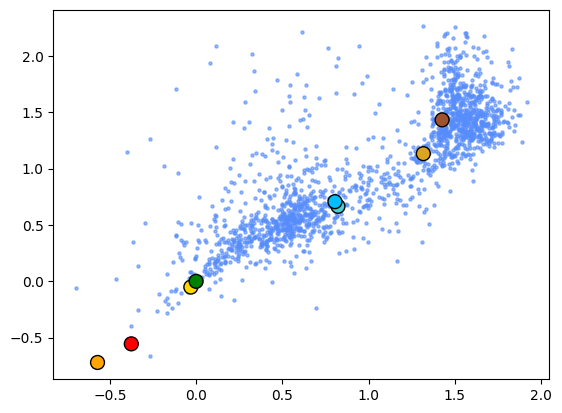

In [4]:
plt.scatter(log_data[:,0], log_data[:,1], s=5, alpha=0.6)
plt.scatter(ss_log[:,0], ss_log[:,1], color=ss_colors, s=100, edgecolors='black')

## BIC calculation

In [5]:
def bic(X):
    bic_scores=[]
    models = dict()
    for k in range(1,10):
        gm=GaussianMixture(n_components=k).fit(X)
        bic_scores.append(gm.bic(X))
        models[k] = gm
    return bic_scores

In [6]:
b1=bic(log_data)
b2=bic(log_data_MR)
b3=bic(log_data_RD)
bics = [b1,b2,b3]


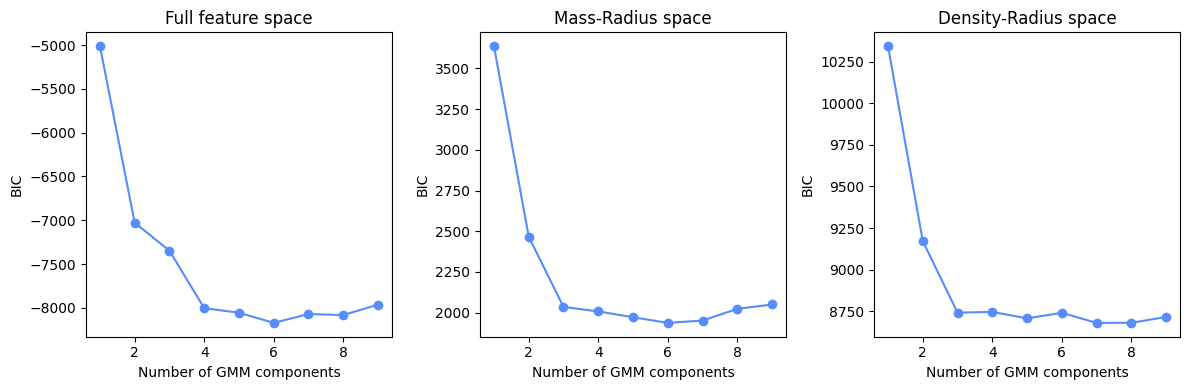

In [7]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.plot(range(1,10), bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('BIC')

plt.tight_layout()
plt.savefig('bic_comparison.png')
plt.show()

In [8]:
def delta_bic(bic):
    delta_bic = []
    for k in range(1,9):
        delta_bic.append(bic[k-1]-bic[k])
    return delta_bic


In [9]:
delta_bics = [delta_bic(b1), delta_bic(b2), delta_bic(b3)]

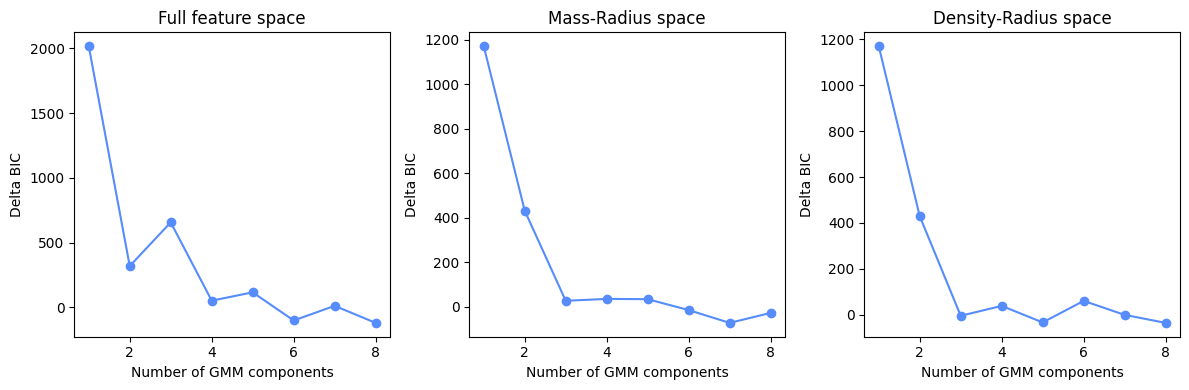

In [10]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.plot(range(1,9), delta_bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('Delta BIC')

plt.tight_layout()
plt.savefig('delta_bic_comparison.png')
plt.show()


## GMM

In [11]:
X_train, X_test = train_test_split(log_data, test_size=0.05, random_state=42)
gmm_best = GaussianMixture(n_components=6, random_state=42)
gmm_best.fit(log_data)
y_train = gmm_best.predict(X_train)
y_test = gmm_best.predict(X_test)
gmm_best.predict(ss_log)

array([3, 3, 3, 3, 5, 1, 3, 3])

In [12]:
gmm_3d_best = GaussianMixture(n_components=5, random_state=42)
gmm_3d_best.fit(log_data[:,:-1])
y_train_3d = gmm_3d_best.predict(X_train[:,:-1])
y_test_3d = gmm_3d_best.predict(X_test[:,:-1])
gmm_3d_best.predict(ss_log[:,:-1])

array([0, 0, 0, 0, 1, 1, 4, 4])

## Plotting results

In [13]:
def plot_results(labels, data, ss_data, ix, iy, ax_labels_array, norm_koeffs=None, ax=None):
    if norm_koeffs is None:
        norm_koeffs = np.ones(len(data[0]))

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ss_colors = ['orange', 'gold', 'green', 'red', 'sienna', 'goldenrod', 'mediumturquoise', 'deepskyblue']

    scatter = ax.scatter(data[:, ix]*norm_koeffs[ix], data[:, iy]*norm_koeffs[iy],
                         c=labels, cmap='tab10', s=5, alpha=0.4)
    scatter_ss = ax.scatter(ss_data[:, ix]*norm_koeffs[ix], ss_data[:, iy]*norm_koeffs[iy], marker='p', color=ss_colors, s=100, edgecolors='black')

    ax.set_xlabel(ax_labels_array[ix])
    ax.set_ylabel(ax_labels_array[iy])
    # ax.set_title('GMM clusters in All feature space')
    plt.colorbar(scatter, ax=ax, label='label')
    plt.tight_layout()
    return ax

In [14]:
labels_gmm = gmm_best.predict(log_data)
labels_gmm_3d = gmm_3d_best.predict(log_data[:,:-1])
lables_array = [r'$\log_{10}(R) [ R_\oplus])$', r'$\log_{10}(M) [ M_\oplus])$',
                r'$\log_{10}(\rho) [g/cm^2])$', r'$\log_{10}(T) [days])$',
                r'$\log_{10}(F) [F_\oplus])$']

<Axes: xlabel='$\\log_{10}(M) [ M_\\oplus])$', ylabel='$\\log_{10}(\\rho) [g/cm^2])$'>

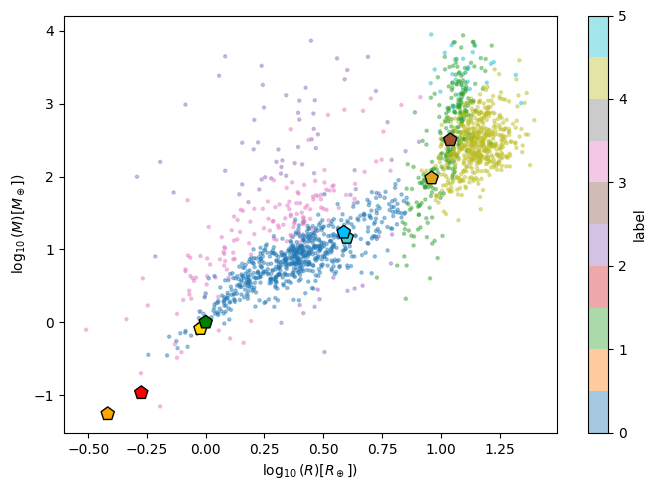

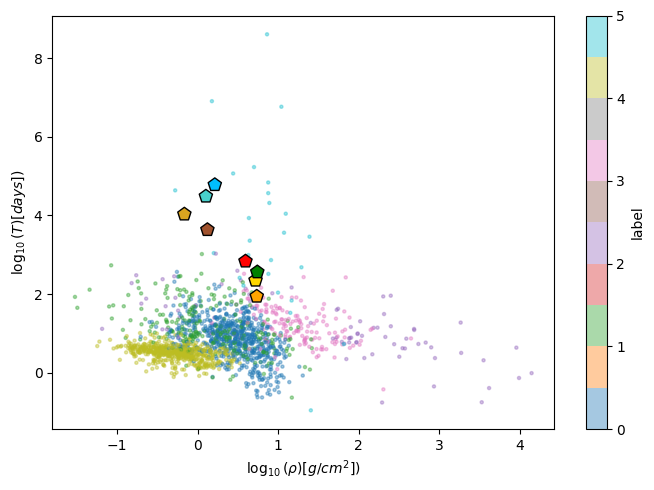

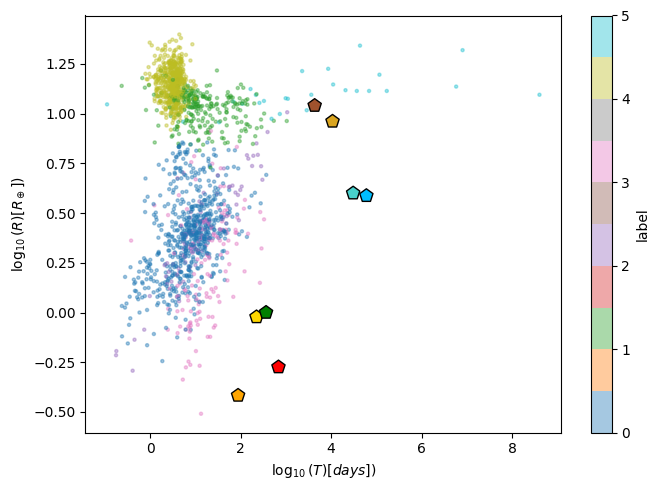

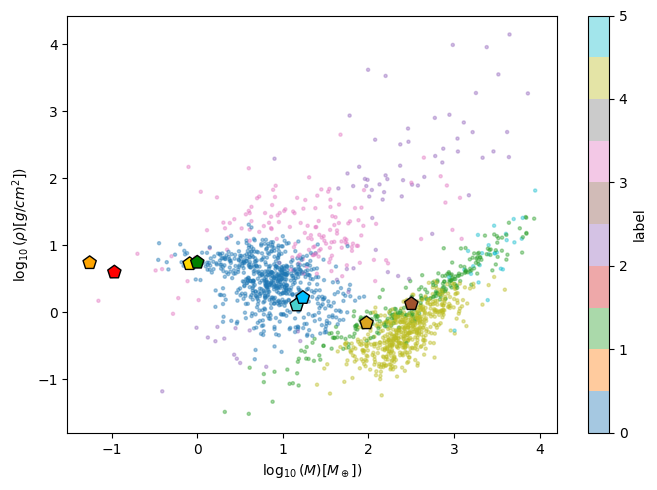

In [15]:
plot_results(labels_gmm, log_data, ss_log, 0, 1, lables_array, norm_koeffs=norm_koeffs)
plot_results(labels_gmm, log_data, ss_log, 2, 3, lables_array, norm_koeffs=norm_koeffs)
plot_results(labels_gmm, log_data, ss_log, 3, 0, lables_array, norm_koeffs=norm_koeffs)
plot_results(labels_gmm, log_data, ss_log, 1, 2, lables_array, norm_koeffs=norm_koeffs)

<Axes: xlabel='$\\log_{10}(M) [ M_\\oplus])$', ylabel='$\\log_{10}(\\rho) [g/cm^2])$'>

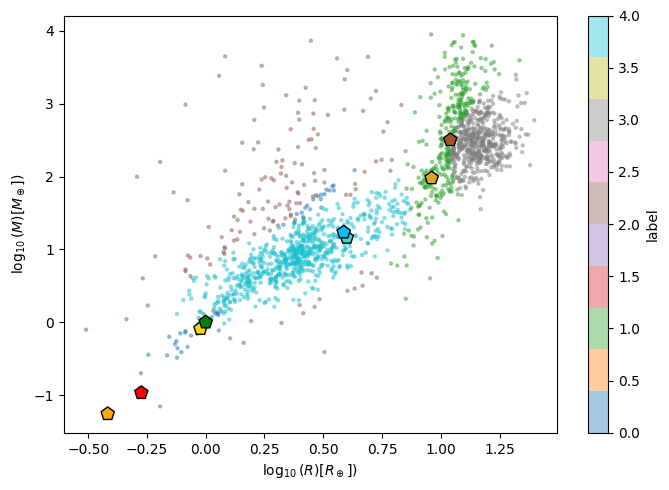

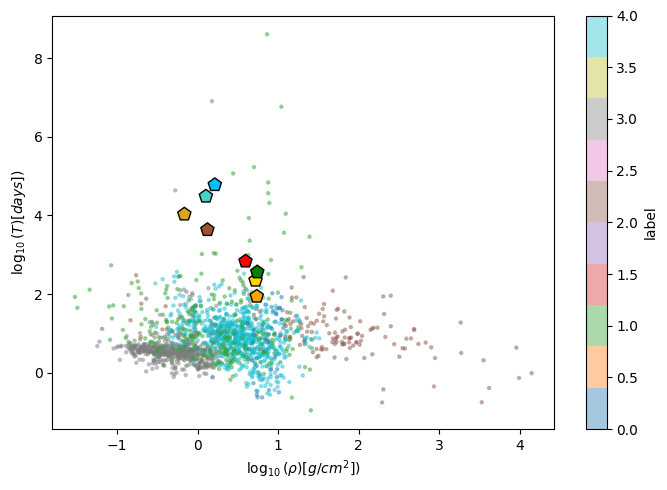

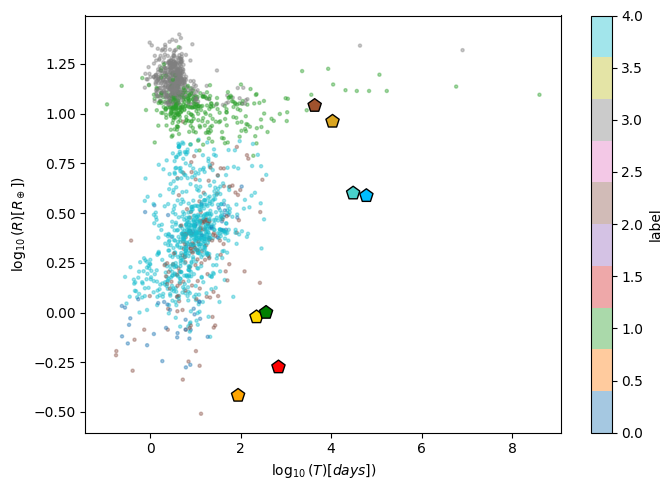

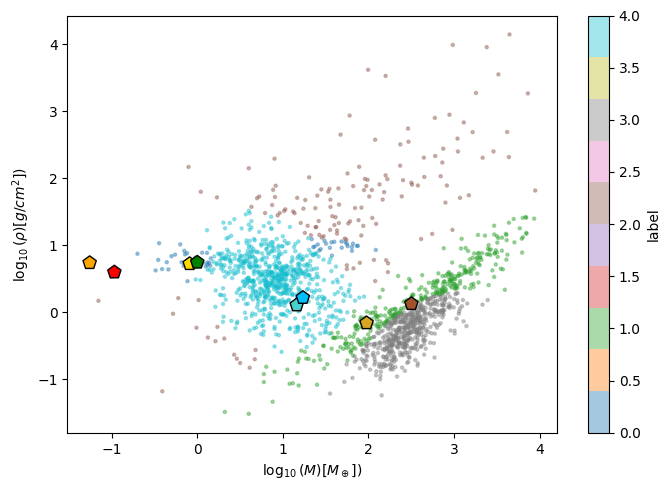

In [16]:
plot_results(labels_gmm_3d, log_data, ss_log, 0, 1, lables_array, norm_koeffs=norm_koeffs)
plot_results(labels_gmm_3d, log_data, ss_log, 2, 3, lables_array, norm_koeffs=norm_koeffs)
plot_results(labels_gmm_3d, log_data, ss_log, 3, 0, lables_array, norm_koeffs=norm_koeffs)
plot_results(labels_gmm_3d, log_data, ss_log, 1, 2, lables_array, norm_koeffs=norm_koeffs)

## KNN

In [17]:
knn = KNeighborsClassifier(n_neighbors=20, weights='distance', p = 2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
knn.predict(ss_log)

array([0, 3, 3, 0, 1, 1, 5, 5])

In [18]:
y_train_all = knn.predict(log_data)

<Axes: xlabel='$\\log_{10}(\\rho) [g/cm^2])$', ylabel='$\\log_{10}(R) [ R_\\oplus])$'>

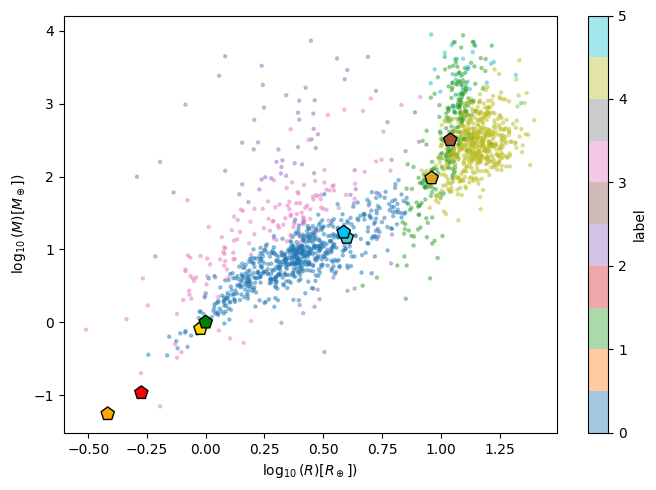

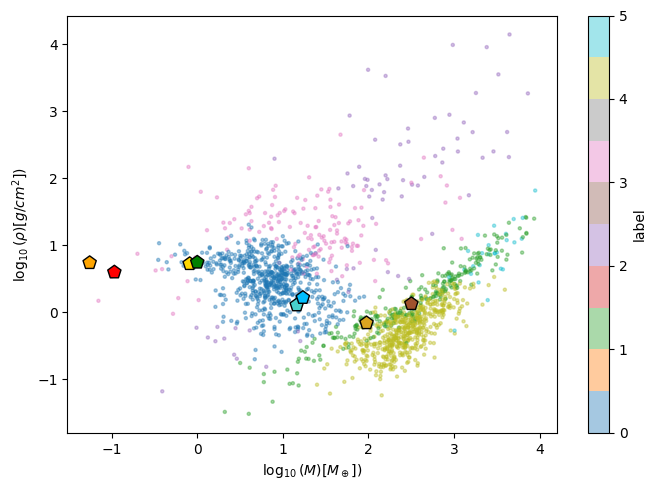

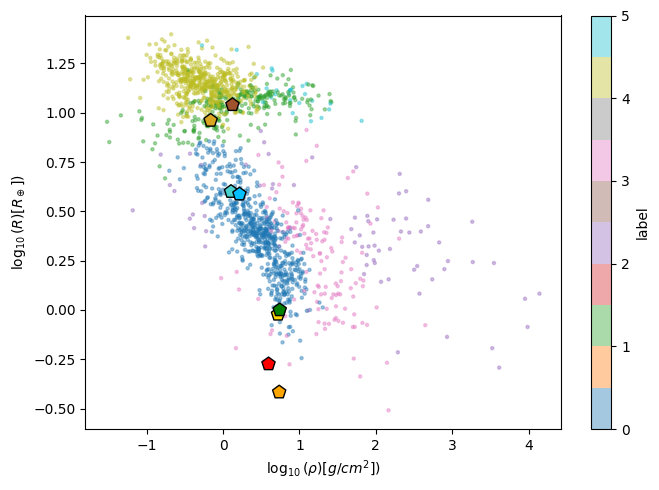

In [19]:
plot_results(y_train_all, log_data, ss_log, 0, 1, lables_array, norm_koeffs=norm_koeffs)
plot_results(y_train_all, log_data, ss_log, 1, 2, lables_array, norm_koeffs=norm_koeffs)
plot_results(y_train_all, log_data, ss_log, 2, 0, lables_array, norm_koeffs=norm_koeffs)

In [20]:
#do accuracy test here
score = knn.score(X_test, y_test)

print(score)

0.9411764705882353


## SVM

In [21]:
svm = LinearSVC()
svm.fit(X_train, y_train)

svm.predict(ss_log)

array([0, 0, 0, 0, 1, 1, 3, 3])

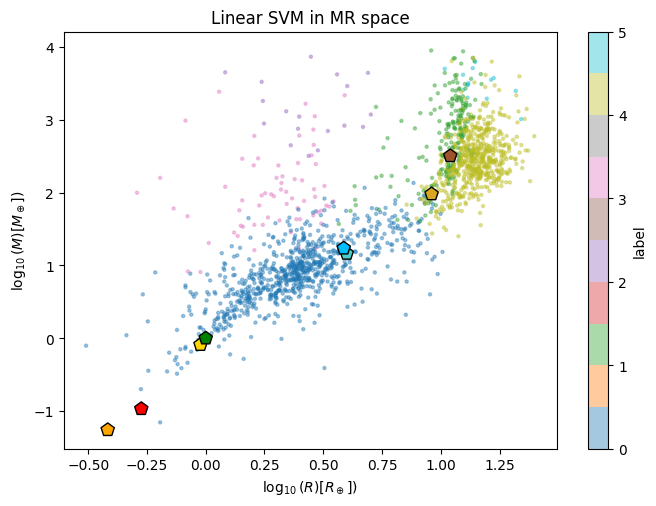

In [22]:
y_train_all = svm.predict(log_data)


plot_results(y_train_all, log_data, ss_log, 0, 1, lables_array, norm_koeffs=norm_koeffs)
plt.title('Linear SVM in MR space')
plt.savefig('svmlinear')

<Axes: xlabel='$\\log_{10}(\\rho) [g/cm^2])$', ylabel='$\\log_{10}(T) [days])$'>

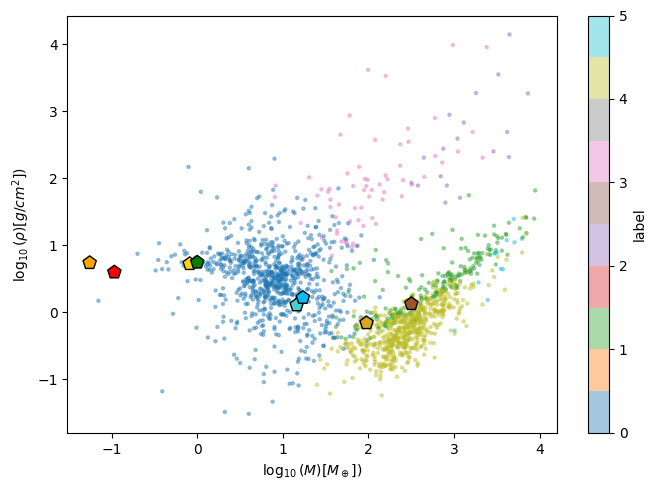

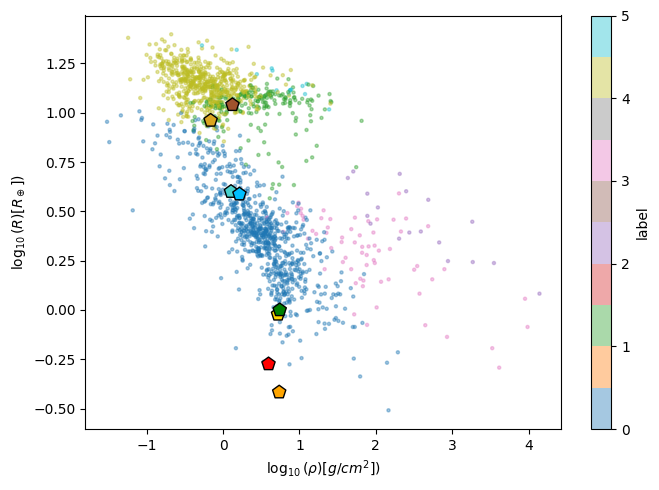

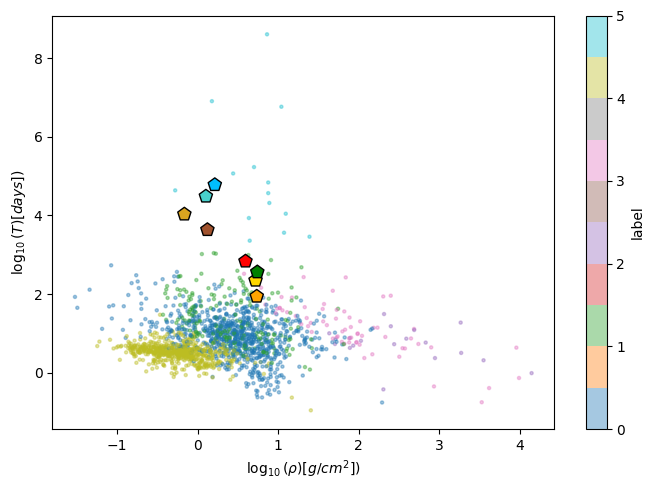

In [23]:
plot_results(y_train_all, log_data, ss_log, 1, 2, lables_array, norm_koeffs=norm_koeffs)
plot_results(y_train_all, log_data, ss_log, 2, 0, lables_array, norm_koeffs=norm_koeffs)
plot_results(y_train_all, log_data, ss_log, 2, 3, lables_array, norm_koeffs=norm_koeffs)

In [24]:
score = svm.score(X_test, y_test)

print(score)

0.8470588235294118


#### Non-linear SVM

In [25]:
svmrbf = SVC()
svmrbf.fit(X_train, y_train)
svmrbf.score(X_test, y_test)


0.9176470588235294

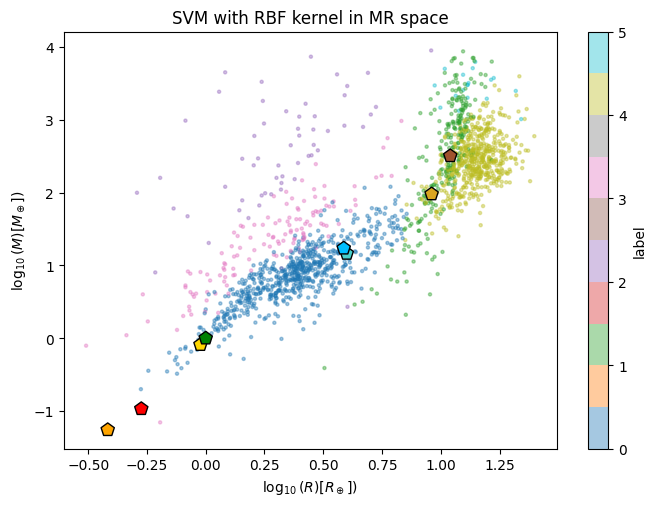

In [26]:
y_train_all = svmrbf.predict(log_data)
plot_results(y_train_all, log_data, ss_log, 0, 1, lables_array, norm_koeffs=norm_koeffs)
plt.title('SVM with RBF kernel in MR space')
plt.savefig('rbfsvm')